### Aim:
To develop regression models for predicting a continuous variable using the Pima Indians Diabetes Dataset and evaluate their performance.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Select BMI as the continuous target variable

target = "BMI"

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

X = df[features].copy()
y = df[target].copy()

print("Target:", target)
print("Features:", features)

Target: BMI
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [6]:
# Replace invalid zero values with NaN

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in invalid_columns:
    df[col] = df[col].replace(0, np.nan)

X = df[features].copy()
y = df[target].copy()

# Fill missing predictor values with median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Remove rows where BMI is missing
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

print("Missing values after preprocessing:")
display(X.isnull().sum())

print("Missing target values:", y.isnull().sum())

Missing values after preprocessing:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing target values: 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 605
Testing samples: 152


In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

display(coefficients)

print("Intercept:", round(model.intercept_, 4))

Linear Regression model trained successfully.


,Feature,Coefficient
0,Pregnancies,-0.057315
1,Glucose,-0.001489
2,BloodPressure,0.126209
3,SkinThickness,0.355430
4,Insulin,0.006049
5,DiabetesPedigreeFunction,1.263166
6,Age,-0.088075
7,Outcome,3.010738


Intercept: 13.8283


In [9]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred,
    "Residual": y_test.values - y_pred
})

display(results.head(10))

,Actual BMI,Predicted BMI,Residual
0,35.7,39.995909,-4.295909
1,26.1,30.470830,-4.370830
2,38.7,40.635664,-1.935664
3,33.3,31.541643,1.758357
4,36.5,38.461379,-1.961379
5,29.3,30.616678,-1.316678
6,37.7,37.152191,0.547809
7,34.0,30.666518,3.333482
8,30.8,30.843183,-0.043183
9,30.4,27.906882,2.493118


In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

========== MODEL PERFORMANCE ==========
MAE  : 4.0625
MSE  : 25.2832
RMSE : 5.0282
R2   : 0.3773


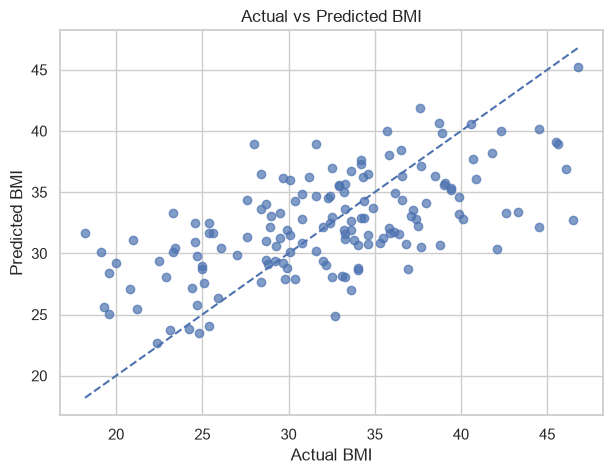

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.7)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")

plt.show()

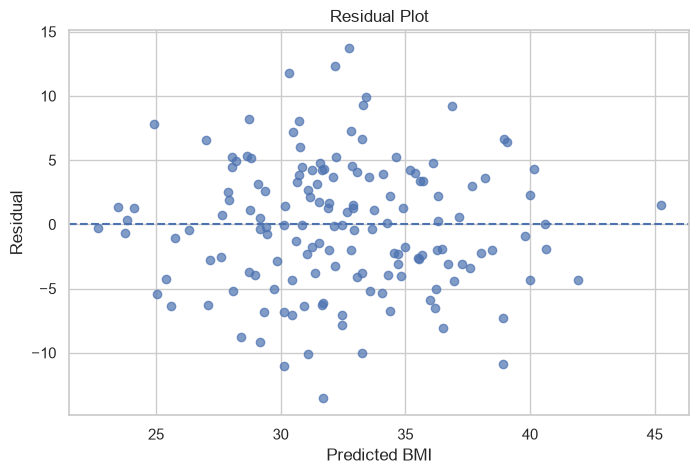

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted BMI")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

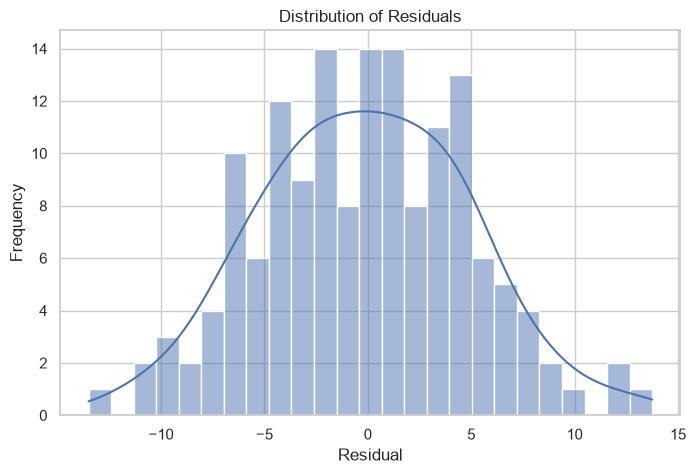

Mean residual: -0.144
Minimum residual: -13.5035
Maximum residual: 13.7524


In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    bins=25,
    kde=True
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

print("Mean residual:", round(residuals.mean(), 4))
print("Minimum residual:", round(residuals.min(), 4))
print("Maximum residual:", round(residuals.max(), 4))

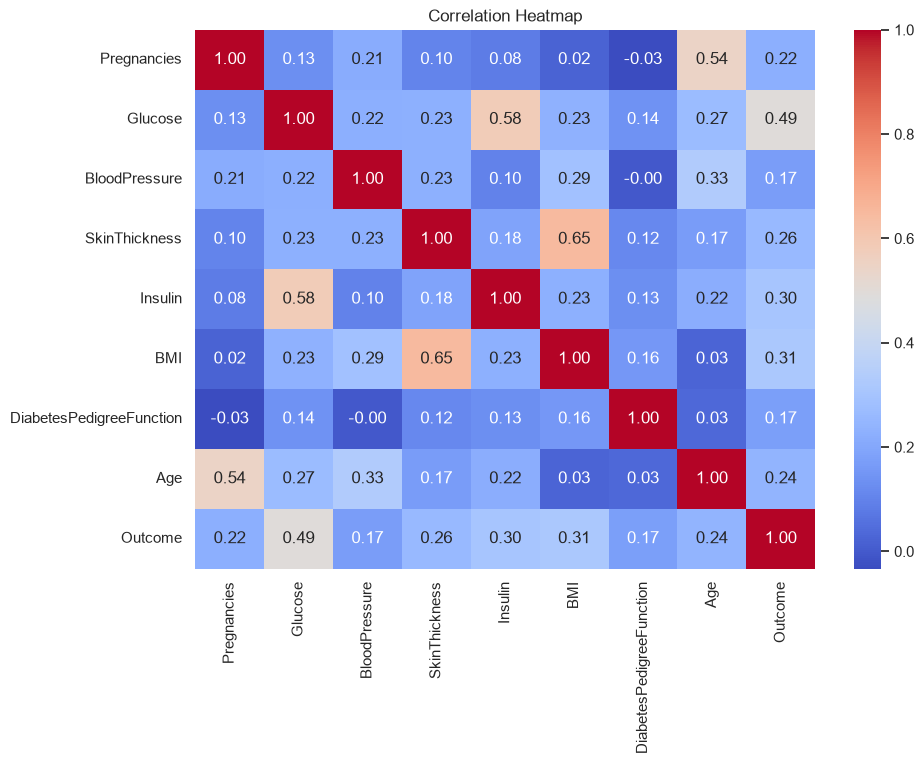

In [14]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
print("========== FINAL RESULTS ==========")
print("Target Variable: BMI")
print("Regression Model: Multiple Linear Regression")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")

========== FINAL RESULTS ==========
Target Variable: BMI
Regression Model: Multiple Linear Regression
MAE  = 4.0625
MSE  = 25.2832
RMSE = 5.0282
R2   = 0.3773
